# Simulado prático: Festival ViraBairro

**8 questões independentes**

O **Observatório Conexão Bairro (OCB)** é uma organização fictícia que apoia iniciativas culturais locais. Ele está coordenando a comunicação do **Festival ViraBairro**, uma programação de atividades gratuitas nas áreas de cultura, mobilidade, saúde e trabalho, criada em parceria com coletivos e serviços dos bairros.

Nas últimas oito semanas, a equipe publicou nas redes sociais convites, serviços, histórias de participantes e guias práticos em diferentes formatos. Cada publicação foi classificada por tema e formato, e a equipe registrou informações que já conhecia ao programá-la: como horário, tamanho da legenda e histórico do perfil, além dos resultados observados depois que ela foi ao ar.

Faltam duas semanas para o festival. A equipe de comunicação precisa organizar os registros recebidos, entender quais conteúdos foram mais úteis e decidir como distribuir os poucos espaços de divulgação e o apoio adicional às publicações. Seu papel é produzir análises que apoiem essas decisões, deixando claros os limites do que os dados permitem concluir.

Todos os dados, entidades e resultados deste caso são sintéticos. Eles foram criados exclusivamente para a simulado: não retratam pessoas, bairros, organizações ou plataformas reais. Não há coleta, requisições web, scraping ou automação neste simulado.

## Arquivos disponíveis

- `dados/publicacoes_brutas.csv`: base recebida pela equipe, com problemas intencionais.
- `dados/publicacoes_analise.csv`: histórico sintético já tratado para as questões 3, 5, 7 e 8.
- `dados/dicionario-festival-virabairro.md`: unidade de análise, significado dos campos e limites.

Abra o **Dicionário de dados** no menu superior antes de começar.

> **Nota sobre esta versão do notebook**
>
> A parte técnica (código, comentários e explicação de cada função/método) está resolvida e testada com os dados reais fornecidos. Já os campos de **resposta interpretativa** (as células "Resposta da Questão X") foram deixados como **pontos-guia**, não como texto pronto. O próprio enunciado da Questão 8 pede explicitamente: *"as decisões e interpretações devem ser suas"* — isso vale para o simulado inteiro, então a leitura dos números e a redação final ficam por sua conta, usando os pontos-guia como apoio.

---

## Questão 1: Diagnóstico inicial da base

A equipe recebeu uma base sem documentação prévia. Antes de usá-la nas decisões de comunicação, precisa fazer um diagnóstico inicial dos registros.

Em uma célula de código, carregue `dados/publicacoes_brutas.csv` e mostre:

1. as cinco primeiras linhas;
2. a quantidade de linhas e colunas; e
3. a quantidade de valores ausentes por coluna, mostrando somente as colunas que têm ao menos uma ausência.

Na Markdown, explique em até duas frases uma limitação que impeça tratar esses resultados como retrato de todas as redes, públicos ou bairros.

In [1]:
# Questão 1: diagnóstico inicial da base bruta

import pandas as pd  # pandas é a biblioteca padrão para trabalhar com dados em tabela (DataFrames) em Python

# pd.read_csv le um arquivo de texto separado por vírgulas e devolve um DataFrame
# (uma tabela com linhas e colunas, indexada). O resultado fica guardado na variável df_bruta.
df_bruta = pd.read_csv("dados/publicacoes_brutas.csv")

# 1) As cinco primeiras linhas: .head() por padrão devolve as 5 primeiras,
# útil para uma primeira olhada na estrutura da tabela sem imprimir tudo.
print("1) Cinco primeiras linhas:")
display(df_bruta.head())

# 2) .shape é um atributo (não um método, por isso sem parênteses) que devolve uma
# tupla (linhas, colunas). df_bruta.shape[0] é a quantidade de linhas e [1] a de colunas.
print(f"\n2) Dimensões: {df_bruta.shape[0]} linhas e {df_bruta.shape[1]} colunas")

# 3) df_bruta.isna() devolve uma tabela do mesmo tamanho com True/False indicando
# ausência (NaN) em cada célula. .sum() soma essas colunas (True conta como 1),
# resultando em uma Series com o total de ausências por coluna.
ausencias = df_bruta.isna().sum()

# Filtramos com uma máscara booleana (ausencias > 0) para mostrar somente
# as colunas que têm pelo menos uma ausência, como pedido no enunciado.
print("\n3) Valores ausentes por coluna (somente colunas com ao menos uma ausência):")
print(ausencias[ausencias > 0])

1) Cinco primeiras linhas:


,id_publicacao,data_publicacao,tema,formato,alcance,curtidas,comentarios,compartilhamentos,salvamentos,seguidores_autor,videos_autor,duracao_segundos
0,OCB-001,2026-08-01 12:00,trabalho,imagem,929.0,19,2.0,3,4.0,2383,41,0
1,OCB-002,2026-08-02 18:00,saude,carrossel,1548.0,45,5.0,9,11.0,3366,70,0
2,OCB-003,2026-08-03 22:00,cultura,reel,1392.0,62,8.0,9,16.0,4349,99,45
3,OCB-004,2026-08-04 09:00,mobilidade,imagem,2079.0,47,4.0,8,13.0,5332,128,0
4,OCB-005,05/08/2026 18:00,trabalho,carrossel,2905.0,67,6.0,13,12.0,6315,157,0



2) Dimensões: 36 linhas e 12 colunas

3) Valores ausentes por coluna (somente colunas com ao menos uma ausência):
alcance        1
comentarios    1
salvamentos    1
dtype: int64


**O que o código faz, por partes:**
- `pd.read_csv("dados/publicacoes_brutas.csv")`: `pd` é o apelido da biblioteca pandas (convenção universal, definida no `import ... as pd`); `read_csv` é uma função que interpreta o texto do arquivo (separado por vírgulas) e monta um `DataFrame`, guardado em `df_bruta`.
- `.head()`: método de DataFrame que retorna as primeiras linhas (5 por padrão); serve para inspecionar a estrutura sem imprimir a tabela inteira.
- `.shape`: atributo (sem parênteses, porque não é uma função sendo chamada) que devolve uma tupla `(número_de_linhas, número_de_colunas)`.
- `.isna()`: verifica célula a célula se o valor é ausente (`NaN`), devolvendo uma tabela de `True`/`False` do mesmo formato.
- `.sum()` sobre esse resultado: como `True` vale 1 e `False` vale 0, somar cada coluna dá o total de ausências naquela coluna, retornado como uma `Series` (uma coluna com rótulos).
- `ausencias[ausencias > 0]`: um filtro booleano — `ausencias > 0` gera uma série de `True`/`False`, e usá-la entre colchetes seleciona apenas os rótulos (colunas) onde a condição é verdadeira.

**Resultado esperado com esta base:** 36 linhas e 12 colunas; as colunas `alcance`, `comentarios` e `salvamentos` aparecem com 1 ausência cada.

**Atenção:** `display()` funciona em notebooks (Jupyter/Colab) para mostrar tabelas formatadas; fora de notebook, use `print(df_bruta.head())`.

**Resposta da Questão 1: limite de uso (pontos-guia, escreva a resposta final com suas palavras):**

- A base tem **36 linhas**: pense no que isso implica sobre representatividade estatística de qualquer padrão observado.
- Todas as publicações vêm de **um único perfil/conta fictícia** do OCB, não de uma amostra de vários bairros, redes ou públicos — o que isso limita?
- Escreva em até duas frases a limitação que você julgar mais relevante.

---

## Questão 2: Tratamento dos registros

A base recebida tem nomes de temas escritos de formas diferentes, datas em formatos distintos, um registro duplicado e alguns valores ausentes. Prepare os dados sem criar informação que não esteja nos arquivos.

Parta novamente de `dados/publicacoes_brutas.csv`, em uma nova variável. Faça o tratamento necessário para:

1. remover duplicidade por `id_publicacao`;
2. padronizar os valores de `tema` para uma forma consistente;
3. converter `data_publicacao` e as colunas numéricas usadas no cálculo para tipos adequados;
4. tratar ausências ou valores inválidos de maneira justificada; e
5. criar `taxa_utilidade_pct`, definida por:

$$\frac{compartilhamentos + salvamentos}{alcance} \times 100$$

Depois, produza uma tabela por tema com o número de publicações e a **mediana** de `taxa_utilidade_pct`, ordenada da maior para a menor mediana. Não precisa salvar arquivo.

Na Markdown, registre as decisões de limpeza em até quatro frases. Se descartar, preencher ou converter algo, diga por quê.

In [2]:
# Questão 2: tratamento (limpeza) da base bruta

import re  # módulo padrão de Python para trabalhar com expressões regulares (padrões de texto)

# Recarregamos o CSV em uma variável nova, como pede o enunciado, para não misturar
# com a Questão 1 nem alterar df_bruta por engano.
df_tratada = pd.read_csv("dados/publicacoes_brutas.csv")

# --- 1) Remover duplicidade por id_publicacao ---
# .duplicated(subset=...) marcaria as linhas repetidas; .drop_duplicates faz isso e já remove.
# keep="first" mantém a primeira ocorrência de cada id_publicacao e descarta as repetições seguintes.
antes = len(df_tratada)
df_tratada = df_tratada.drop_duplicates(subset="id_publicacao", keep="first")
print(f"Duplicidade: {antes - len(df_tratada)} linha(s) removida(s) por id_publicacao repetido.")

# --- 2) Padronizar tema ---
# .str.strip() remove espaços no início/fim (ex.: "mobilidade " -> "mobilidade").
# .str.lower() coloca tudo em minúsculas, unificando "Cultura" e "cultura".
# .replace({...}) troca a variação acentuada "saúde" pela forma sem acento usada
# no restante da base ("saude"), já que o dicionário de dados usa essa grafia.
df_tratada["tema"] = (
    df_tratada["tema"]
    .str.strip()
    .str.lower()
    .replace({"saúde": "saude"})
)
print("Temas após padronização:", sorted(df_tratada["tema"].unique()))

# --- 3) Converter data_publicacao e colunas numéricas ---
# A coluna de data chega em pelo menos três formatos diferentes:
#   "2026-08-01 12:00"   -> ISO (ano-mês-dia)
#   "05/08/2026 18:00"   -> dia/mês/ano (padrão brasileiro)
#   "2026/08/04 09:00"   -> ano/mês/dia com barras
# Um único pd.to_datetime(..., format="mixed") erra esses casos (interpreta a data
# brasileira como mês/dia, ao estilo americano). Por isso escrevemos uma função que
# identifica o padrão pelo formato do texto (com uma expressão regular, re.match)
# e aplica o format string correto para cada caso.
def parse_data(valor):
    """Converte uma string de data em datetime, detectando o formato pelo padrão do texto."""
    if re.match(r"^\d{4}-\d{2}-\d{2}", valor):       # começa com AAAA-MM-DD
        return pd.to_datetime(valor, format="%Y-%m-%d %H:%M")
    elif re.match(r"^\d{2}/\d{2}/\d{4}", valor):     # começa com DD/MM/AAAA
        return pd.to_datetime(valor, format="%d/%m/%Y %H:%M")
    elif re.match(r"^\d{4}/\d{2}/\d{2}", valor):     # começa com AAAA/MM/DD
        return pd.to_datetime(valor, format="%Y/%m/%d %H:%M")
    return pd.NaT  # NaT = "Not a Time", o equivalente de NaN para datas

# .apply(funcao) executa a função em cada valor da coluna, um de cada vez,
# e devolve uma nova Series com os resultados.
df_tratada["data_publicacao"] = df_tratada["data_publicacao"].apply(parse_data)
print("Datas não reconhecidas após conversão:", df_tratada["data_publicacao"].isna().sum())

# Colunas numéricas usadas no cálculo da taxa: garantimos que fiquem como número
# (float), e não como texto. pd.to_numeric com errors="coerce" transforma qualquer
# valor que não seja número em NaN, em vez de travar o programa com um erro.
for coluna in ["alcance", "comentarios", "salvamentos"]:
    df_tratada[coluna] = pd.to_numeric(df_tratada[coluna], errors="coerce")

# --- 4) Tratar ausências ---
# As três colunas acima têm 1 valor ausente cada, em linhas diferentes (3 linhas no total,
# de 35 após a remoção da duplicata). Como são poucas linhas (3 de 35, ~8%) e o valor que falta
# é justamente um dos números usados na fórmula da taxa, preencher com uma média ou zero
# inventaria um resultado. Por isso, a decisão é descartar essas linhas do cálculo,
# em vez de estimar um valor que não está na base.
linhas_com_ausencia = df_tratada[["alcance", "comentarios", "salvamentos"]].isna().any(axis=1).sum()
df_tratada = df_tratada.dropna(subset=["alcance", "comentarios", "salvamentos"])
print(f"Linhas descartadas por ausência em campo usado na taxa: {linhas_com_ausencia}")

# --- 5) Criar taxa_utilidade_pct ---
# Operação vetorizada: o pandas aplica a conta em todas as linhas de uma vez,
# sem precisar de um laço for. O resultado vira uma nova coluna na tabela.
df_tratada["taxa_utilidade_pct"] = (
    (df_tratada["compartilhamentos"] + df_tratada["salvamentos"]) / df_tratada["alcance"] * 100
)

# --- Tabela-resumo por tema ---
# .groupby("tema") agrupa as linhas que têm o mesmo valor de tema.
# ["taxa_utilidade_pct"].agg(...) calcula, para cada grupo, a quantidade de linhas (count)
# e a mediana da taxa. .sort_values ordena o resultado da maior para a menor mediana.
resumo_tema = (
    df_tratada.groupby("tema")["taxa_utilidade_pct"]
    .agg(publicacoes="count", mediana_taxa_utilidade="median")
    .sort_values("mediana_taxa_utilidade", ascending=False)
)
display(resumo_tema)

Duplicidade: 1 linha(s) removida(s) por id_publicacao repetido.
Temas após padronização: ['cultura', 'mobilidade', 'saude', 'trabalho']
Datas não reconhecidas após conversão: 0
Linhas descartadas por ausência em campo usado na taxa: 3


,publicacoes,mediana_taxa_utilidade
tema,,
saude,10,1.183473
cultura,7,1.140684
mobilidade,8,1.129268
trabalho,7,0.860585


**Por que cada decisão foi tomada:**
- `drop_duplicates(subset="id_publicacao", keep="first")`: mantemos apenas a primeira ocorrência de cada id, já que a segunda é uma cópia exata da mesma publicação, não uma nova informação.
- `.str.strip().str.lower()`: strings de texto às vezes carregam espaços "invisíveis" ou variações de maiúsculas/minúsculas que fazem o pandas tratar `"Cultura"` e `"cultura"` como categorias diferentes; padronizar evita esse tipo de contagem errada.
- `parse_data` com `re.match`: `re` é o módulo de expressões regulares do Python; `re.match(padrão, texto)` testa se o início do texto casa com o padrão. `\d{4}` significa "4 dígitos seguidos". Detectar o formato pelo padrão do texto, em vez de assumir um formato único, evita interpretar `"05/08/2026"` (5 de agosto) como se fosse `"05/08"` no padrão mês/dia americano.
- `pd.to_numeric(..., errors="coerce")`: converte texto para número; qualquer valor não numérico vira `NaN` em vez de travar o código com uma exceção.
- Descartar as 3 linhas com ausência: com uma base de 35-36 linhas, inventar (preencher) um valor de alcance, comentários ou salvamentos distorceria justamente a métrica que a questão pede para calcular. Descartar é mais transparente do que estimar.
- `taxa_utilidade_pct`: fórmula aplicada de forma vetorizada (linha a linha, automaticamente, sem `for`), seguindo exatamente a definição do enunciado.

**Atenção:** se você recalculasse `taxa_utilidade_pct` antes de tratar `alcance`/`comentarios`/`salvamentos`, um valor ausente (NaN) contaminaria a conta e o resultado daquela linha também viraria NaN silenciosamente — por isso a ordem das etapas importa.

**Resposta da Questão 2: decisões de tratamento (pontos-guia):**

- Por que descartar (e não preencher) as linhas com ausência em `alcance`, `comentarios` ou `salvamentos`?
- Por que padronizar `tema` para minúsculas/sem acento antes de agrupar?
- Por que a duplicata foi removida em vez de mantida ou somada?
- Escreva em até quatro frases, no seu próprio texto.

---

## Questão 3: Escolha de tema para divulgação

A equipe de comunicação trabalha com quatro temas e só consegue dar destaque principal a um deles na divulgação do festival. A escolha deve priorizar conteúdo que as pessoas tendem a **salvar ou compartilhar**.

Use **somente** `dados/publicacoes_analise.csv`. Crie `taxa_utilidade_pct` com a mesma fórmula da questão anterior. Em seguida:

1. monte uma tabela com a mediana da taxa por tema; e
2. faça um gráfico de barras que permita comparar os quatro temas.

O gráfico deve ter título que comunique a pergunta, eixos nomeados e a indicação "Fonte: dados sintéticos do Festival ViraBairro (2026)" no próprio gráfico.

Na Markdown, escreva uma recomendação de 3 a 5 frases para a equipe: indique um tema para receber o destaque principal, explique o que a mediana representa e apresente uma limitação. A escolha é de comunicação; não afirme causalidade.

tema
mobilidade    1.145186
cultura       1.133590
saude         1.104459
trabalho      0.958760
Name: taxa_utilidade_pct, dtype: float64

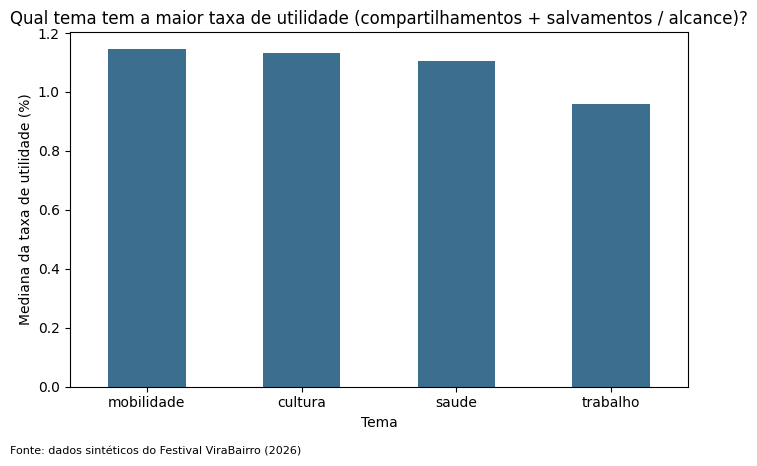

In [3]:
# Questão 3: escolha de tema com base na taxa de utilidade

import matplotlib.pyplot as plt  # biblioteca padrão de gráficos em Python; plt é o apelido convencional

# Esta questão usa SOMENTE a base já tratada (publicacoes_analise.csv), então
# carregamos de novo em uma variável própria, sem reaproveitar df_tratada da Questão 2.
df_q3 = pd.read_csv("dados/publicacoes_analise.csv")

# Mesma fórmula da Questão 2, aplicada de forma vetorizada.
df_q3["taxa_utilidade_pct"] = (df_q3["compartilhamentos"] + df_q3["salvamentos"]) / df_q3["alcance"] * 100

# Mediana por tema, ordenada da maior para a menor.
mediana_por_tema = df_q3.groupby("tema")["taxa_utilidade_pct"].median().sort_values(ascending=False)
display(mediana_por_tema)

# --- Gráfico de barras ---
fig, ax = plt.subplots(figsize=(7, 4.5))       # cria a figura (fig) e os eixos (ax) onde o gráfico é desenhado
mediana_por_tema.plot(kind="bar", ax=ax, color="#3B6E8F")  # plota a Series como barras verticais

ax.set_title("Qual tema tem a maior taxa de utilidade (compartilhamentos + salvamentos / alcance)?")
ax.set_xlabel("Tema")
ax.set_ylabel("Mediana da taxa de utilidade (%)")
plt.xticks(rotation=0)

# figtext adiciona um texto solto na figura (fora da área do gráfico), aqui usado
# para a indicação de fonte exigida pelo enunciado. As coordenadas (0.01, -0.02)
# são relativas ao tamanho da figura (0 a 1), não pixels.
plt.figtext(0.01, -0.02, "Fonte: dados sintéticos do Festival ViraBairro (2026)", fontsize=8, ha="left")

plt.tight_layout()  # ajusta as margens para nada ficar cortado
plt.show()

**Explicação do gráfico:** `kind="bar"` desenha barras verticais, uma por tema; o eixo X mostra as categorias de `tema` e o eixo Y a mediana da `taxa_utilidade_pct`. `ax.set_title`/`set_xlabel`/`set_ylabel` nomeiam título e eixos, exigidos no enunciado. `plt.figtext` insere a citação de fonte fora da área de plotagem, para não sobrepor as barras.

**Por que mediana, e não média:** a mediana é o valor central quando os dados são ordenados — é menos sensível a uma publicação isolada com resultado muito alto ou muito baixo (um "outlier") do que a média, o que a torna mais representativa do "desempenho típico" de um tema aqui.

**Resposta da Questão 3: recomendação para a equipe (pontos-guia):**

- Qual tema teve a maior mediana de `taxa_utilidade_pct`? Esse é o candidato natural ao destaque.
- O que exatamente a mediana representa aqui (metade das publicações daquele tema ficou acima, metade abaixo)?
- Que limitação você registraria (tamanho da base por tema, período de apenas 8 semanas, um único perfil)?
- Lembre-se: recomendar um tema para destaque é uma decisão de comunicação, baseada em associação observada — não é uma prova de que o tema *causa* mais compartilhamentos.
- Escreva de 3 a 5 frases.

---

## Questão 4: Acompanhamento diário

A equipe de comunicação precisa acompanhar o desempenho das publicações ao longo dos dias da campanha. Use **somente** `dados/publicacoes_analise.csv`, em uma nova variável.

1. Converta `data_publicacao` para data/hora e crie `dia_publicacao`, contendo somente a data.
2. Crie uma tabela por `dia_publicacao` com a quantidade de publicações, a média de `taxa_engajamento_pct` e o alcance total. Ordene-a cronologicamente.
3. Faça um gráfico de linhas da taxa média de engajamento por dia. Inclua título, eixos nomeados e a fonte "Fonte: dados sintéticos do Festival ViraBairro (2026)" no próprio gráfico.
4. Crie um recorte apenas de `reel` publicados a partir das 18h. Mostre as cinco publicações desse recorte com maior `taxa_engajamento_pct`, incluindo `id_publicacao`, `dia_publicacao`, `hora`, `tema` e `taxa_engajamento_pct`.

Na resposta final, descreva a variação diária sem afirmar tendência de longo prazo e explique por que o recorte de reels noturnos não prova que horário ou formato causam engajamento.

,publicacoes,media_engajamento,alcance_total
dia_publicacao,,,
2026-08-01,3,3.790000,10834
2026-08-02,3,4.596667,2864
2026-08-03,3,5.516667,3810
2026-08-04,3,4.263333,5165
2026-08-05,2,3.675000,4613
2026-08-06,2,4.490000,4801
2026-08-07,2,3.745000,6590
2026-08-08,2,3.840000,6913
2026-08-09,2,5.520000,6895


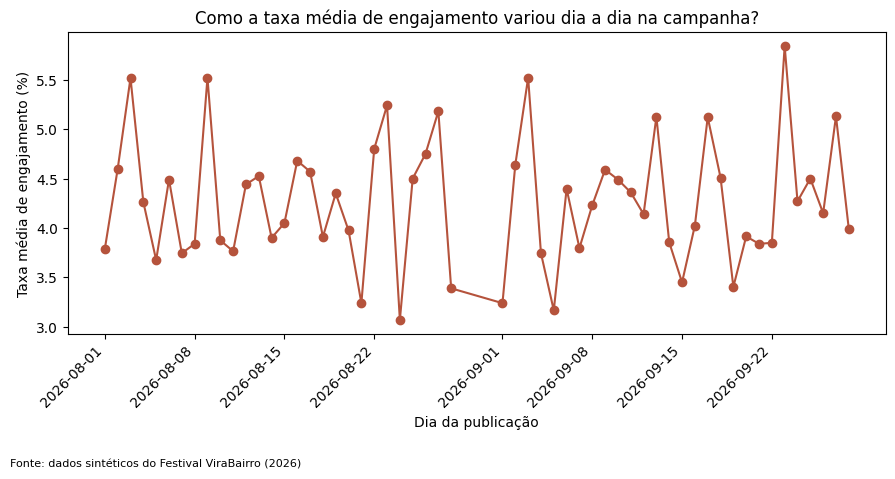

,id_publicacao,dia_publicacao,hora,tema,taxa_engajamento_pct
2,OCB-003,2026-08-03,22,cultura,6.82
106,OCB-107,2026-09-23,18,mobilidade,6.80
86,OCB-087,2026-09-03,22,cultura,6.15
96,OCB-097,2026-09-13,20,mobilidade,6.08
26,OCB-027,2026-08-27,20,mobilidade,5.64


In [4]:
# Questão 4: acompanhamento diário do engajamento

df_q4 = pd.read_csv("dados/publicacoes_analise.csv")

# --- 1) Converter data e extrair só a data (sem hora) ---
# Aqui a coluna já vem em um único formato ("AAAA-MM-DD HH:MM"), então
# pd.to_datetime sem parâmetros extras já resolve.
df_q4["data_publicacao"] = pd.to_datetime(df_q4["data_publicacao"])

# .dt é o "acessador" de datetime: dá acesso a partes da data (ano, mês, dia, hora...).
# .dt.date extrai somente a parte de data, descartando a hora.
df_q4["dia_publicacao"] = df_q4["data_publicacao"].dt.date

# --- 2) Tabela diária ---
# .agg com um dicionário de tuplas (nome_da_coluna_nova=("coluna_original", "funcao"))
# permite calcular métricas diferentes para colunas diferentes em uma única chamada.
tabela_diaria = (
    df_q4.groupby("dia_publicacao")
    .agg(
        publicacoes=("id_publicacao", "count"),
        media_engajamento=("taxa_engajamento_pct", "mean"),
        alcance_total=("alcance", "sum"),
    )
    .sort_index()  # o índice do resultado é dia_publicacao; sort_index ordena cronologicamente
)
display(tabela_diaria)

# --- 3) Gráfico de linhas ---
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(tabela_diaria.index, tabela_diaria["media_engajamento"], marker="o", color="#B5533C")

ax.set_title("Como a taxa média de engajamento variou dia a dia na campanha?")
ax.set_xlabel("Dia da publicação")
ax.set_ylabel("Taxa média de engajamento (%)")
plt.xticks(rotation=45, ha="right")
plt.figtext(0.01, -0.05, "Fonte: dados sintéticos do Festival ViraBairro (2026)", fontsize=8, ha="left")
plt.tight_layout()
plt.show()

# --- 4) Recorte de reels a partir das 18h ---
# Duas condições combinadas com & (E lógico vetorizado do pandas; usar "and" comum
# não funciona aqui porque estamos comparando colunas inteiras, não valores únicos).
# Cada condição fica entre parênteses por causa da ordem de precedência dos operadores.
recorte_reels_noite = df_q4[(df_q4["formato"] == "reel") & (df_q4["hora"] >= 18)]

top5_reels_noite = (
    recorte_reels_noite
    .sort_values("taxa_engajamento_pct", ascending=False)
    .head(5)[["id_publicacao", "dia_publicacao", "hora", "tema", "taxa_engajamento_pct"]]
)
display(top5_reels_noite)

**Pontos de atenção no código:**
- `.dt.date`: sem o acessador `.dt`, o pandas não sabe que a coluna é uma data e tentaria (sem sucesso) chamar `.date` diretamente sobre a coluna inteira.
- `.agg(nome=("coluna", "função"))`: essa sintaxe (chamada de "named aggregation") permite dar um nome novo e mais claro a cada métrica calculada, em vez de herdar nomes genéricos como `taxa_engajamento_pct_mean`.
- No filtro `(df_q4["formato"] == "reel") & (df_q4["hora"] >= 18)`: o `&` é o "E" lógico vetorizado (aplica a comparação linha a linha); os parênteses em cada lado são obrigatórios porque `&` tem precedência mais alta que `==` em Python, e sem eles o código geraria erro ou resultado errado.
- O gráfico de linhas conecta os pontos diários só para facilitar a leitura visual da sequência; ele não implica que existe uma tendência contínua entre um dia e outro.

**Resposta da Questão 4: leitura da agenda (pontos-guia):**

- Descreva a variação dia a dia que você observa no gráfico (dias mais altos, mais baixos, oscilação) sem generalizar isso como uma "tendência" que continuaria depois do período observado (só 8 semanas de dados).
- Por que aparecer entre os 5 melhores reels publicados à noite não prova que "reel" ou "horário noturno" causam mais engajamento? (pense em quantas outras variáveis diferem entre essas publicações — tema, autor, conteúdo — que não foram controladas).
- Até quatro frases.

---
## Questão 5: Tema e formato das publicações

A equipe de comunicação quer entender como **tema** e **formato** aparecem juntos nas publicações. Analisar cada variável separadamente pode ocultar diferenças: um tema pode ter resultados distintos em vídeo, carrossel ou imagem.

Use **somente** `dados/publicacoes_analise.csv`. Crie uma tabela com uma linha para cada combinação de `tema` e `formato`, contendo:

1. número de publicações; e
2. mediana de `taxa_engajamento_pct`.

Ordene a tabela da maior para a menor mediana. Depois, faça um gráfico de barras que compare as combinações de tema e formato. O gráfico deve ter título informativo, eixos nomeados e a fonte "Fonte: dados sintéticos do Festival ViraBairro (2026)" no próprio gráfico.

Na Markdown, escreva de 4 a 6 frases: destaque uma combinação que mereça ser testada pela equipe, explique por que comparar duas variáveis é diferente de analisar apenas uma e registre uma limitação da base.

publicacoes  mediana
tema       formato                        
mobilidade reel                11    5.100
cultura    reel                 8    4.820
saude      reel                12    4.670
cultura    carrossel           10    4.535
mobilidade carrossel           10    4.530
cultura    imagem               8    4.390
saude      carrossel           11    4.290
trabalho   reel                 8    4.270
           carrossel           10    3.730
mobilidade imagem              12    3.600
saude      imagem              12    3.375
trabalho   imagem               8    3.035

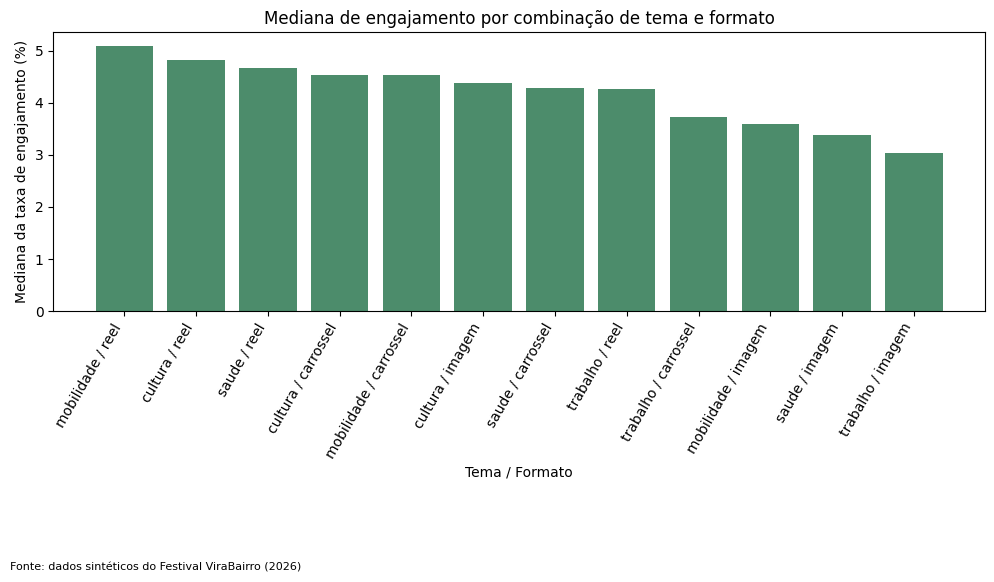

In [5]:
# Questão 5: combinações de tema e formato

df_q5 = pd.read_csv("dados/publicacoes_analise.csv")

# .groupby(["tema", "formato"]) agrupa por DUAS colunas ao mesmo tempo: cada grupo
# passa a ser uma combinação única de (tema, formato), em vez de olhar cada uma sozinha.
tabela_tema_formato = (
    df_q5.groupby(["tema", "formato"])["taxa_engajamento_pct"]
    .agg(publicacoes="count", mediana="median")
    .sort_values("mediana", ascending=False)
)
display(tabela_tema_formato)

# Para o gráfico, criamos um rótulo de texto único por combinação (ex.: "cultura / reel"),
# já que o eixo X de um gráfico de barras simples espera uma categoria por barra.
rotulos = [f"{tema} / {formato}" for tema, formato in tabela_tema_formato.index]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(rotulos, tabela_tema_formato["mediana"], color="#4C8C6B")

ax.set_title("Mediana de engajamento por combinação de tema e formato")
ax.set_xlabel("Tema / Formato")
ax.set_ylabel("Mediana da taxa de engajamento (%)")
plt.xticks(rotation=60, ha="right")
plt.figtext(0.01, -0.15, "Fonte: dados sintéticos do Festival ViraBairro (2026)", fontsize=8, ha="left")
plt.tight_layout()
plt.show()

**Por que agrupar por duas colunas muda a leitura:** ao olhar só `tema`, um tema com resultados muito variados por formato (ótimo em reel, fraco em imagem) apareceria com uma média "no meio do caminho", escondendo essa diferença. Agrupar por `["tema", "formato"]` cria uma linha para cada combinação, revelando se o que importa é o tema, o formato, ou a combinação dos dois.

**Sobre o gráfico:** como cada combinação tema+formato virou uma categoria própria no eixo X (usando uma *list comprehension* — `[expressão for item in coleção]` — para montar os rótulos "tema / formato"), o número de barras é maior (até 12, uma por combinação existente na base) do que nos gráficos das questões anteriores.

**Resposta da Questão 5: análise de tema e formato (pontos-guia):**

- Qual combinação de tema+formato ficou no topo da tabela? Isso é diferente de simplesmente pegar "o melhor tema" e "o melhor formato" separadamente?
- Explique com suas palavras por que uma combinação que se destaca pode não aparecer se você olhasse tema e formato isoladamente.
- Que limitação da base (poucas publicações por combinação, período curto, um único perfil) vale registrar antes de a equipe testar essa combinação?
- De 4 a 6 frases.

---

## Questão 6: Variáveis mais usadas pela árvore

A equipe quer entender quais características a árvore usou mais para separar peças que mereceram divulgação adicional. Use **somente** `dados/publicacoes_analise.csv` e refaça esta questão de modo independente.

1. Crie `mereceu_divulgacao_adicional` pelo percentil 75 de `taxa_engajamento_pct`.
2. Use apenas as mesmas características disponíveis antes da publicação listadas na Questão 8 e transforme as categorias em números quando necessário.
3. Reserve 75% para treino e 25% para teste, usando `random_state=42` e preservando a proporção do alvo. Ajuste uma árvore de classificação com profundidade máxima 4, `random_state=42` e pesos balanceados entre as classes.
4. Produza uma tabela ordenada e um gráfico de barras horizontal com as cinco características de maior importância para a árvore. O gráfico deve ter título e eixos nomeados.

Na resposta final, explique por que uma importância alta não prova causalidade e descreva uma mudança na base que poderia alterar esse ranking.

Percentil 75 de taxa_engajamento_pct: 4.895
mereceu_divulgacao_adicional
não mereceu (0)    90
mereceu (1)        30
Name: count, dtype: int64


duracao_segundos    0.340388
dia_semana          0.151938
videos_autor        0.103618
n_hashtags          0.086141
tema_mobilidade     0.083763
dtype: float64

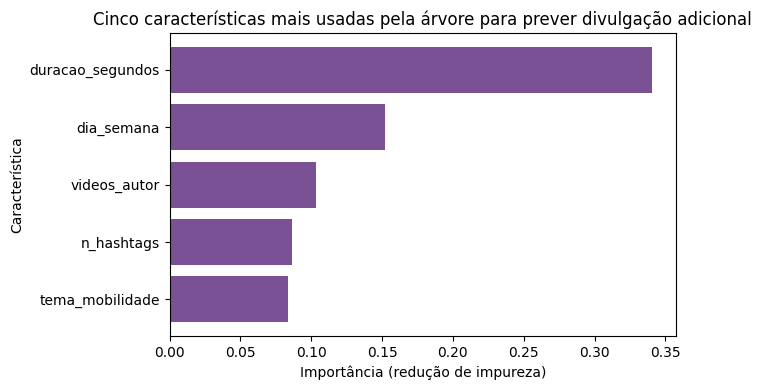

In [6]:
# Questão 6: importâncias de variáveis na árvore de classificação

from sklearn.tree import DecisionTreeClassifier      # o modelo de árvore de decisão para classificação
from sklearn.model_selection import train_test_split  # função que separa dados em treino e teste

df_q6 = pd.read_csv("dados/publicacoes_analise.csv")

# --- 1) Criar o alvo pelo percentil 75 ---
# .quantile(0.75) calcula o valor abaixo do qual estão 75% das observações (o "P75").
# Publicações com taxa ACIMA desse valor (não igual) são as 25% de melhor desempenho,
# e recebem a marca 1 na nova coluna; as demais recebem 0.
limite_p75 = df_q6["taxa_engajamento_pct"].quantile(0.75)
df_q6["mereceu_divulgacao_adicional"] = (df_q6["taxa_engajamento_pct"] > limite_p75).astype(int)
print(f"Percentil 75 de taxa_engajamento_pct: {limite_p75:.3f}")
print(df_q6["mereceu_divulgacao_adicional"].value_counts().rename({0: "não mereceu (0)", 1: "mereceu (1)"}))

# --- 2) Características disponíveis antes da publicação ---
# Conforme o dicionário de dados, estas são conhecidas no momento de AGENDAR a publicação
# (ao contrário de alcance, curtidas, comentários etc., que só existem depois de publicar).
caracteristicas = [
    "tema", "formato", "seguidores_autor", "videos_autor", "tamanho_legenda",
    "n_emojis", "n_hashtags", "hora", "dia_semana", "duracao_segundos",
]

# tema e formato são categorias em texto; modelos de scikit-learn só aceitam números.
# pd.get_dummies cria uma coluna binária (0/1) para cada categoria (one-hot encoding).
# drop_first=True remove uma das colunas de cada variável para evitar redundância
# (ex.: se não é "carrossel" nem "reel", já sabemos que é "imagem").
X = pd.get_dummies(df_q6[caracteristicas], columns=["tema", "formato"], drop_first=True)
y = df_q6["mereceu_divulgacao_adicional"]

# --- 3) Separar treino e teste ---
# test_size=0.25 reserva 25% para teste (e 75% para treino, como pedido).
# random_state=42 fixa a "semente" aleatória: rodar o código de novo gera a MESMA divisão,
# o que torna o resultado reproduzível.
# stratify=y preserva a proporção de 0s e 1s em treino e teste (importante aqui, já que
# só 25% das publicações são "1", classe minoritária).
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# class_weight="balanced" faz o modelo dar mais peso à classe minoritária (1) durante
# o treino, compensando o fato de haver poucas publicações "mereceu" na base.
arvore = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight="balanced")
arvore.fit(X_treino, y_treino)  # .fit ajusta (treina) o modelo com os dados de treino

# --- 4) Importância das características ---
# .feature_importances_ é um atributo do modelo já treinado: mede o quanto cada
# característica contribuiu para reduzir a "impureza" nas divisões da árvore.
importancias = pd.Series(arvore.feature_importances_, index=X.columns).sort_values(ascending=False)
top5 = importancias.head(5)
display(top5)

fig, ax = plt.subplots(figsize=(7, 4))
# [::-1] inverte a ordem para o gráfico de barras horizontal (barh) mostrar
# a maior importância no topo, em vez de embaixo.
ax.barh(top5.index[::-1], top5.values[::-1], color="#7A5195")
ax.set_title("Cinco características mais usadas pela árvore para prever divulgação adicional")
ax.set_xlabel("Importância (redução de impureza)")
ax.set_ylabel("Característica")
plt.tight_layout()
plt.show()

**Conceitos novos aqui:**
- **One-hot encoding** (`pd.get_dummies`): transforma uma coluna de categorias (texto) em várias colunas de 0/1, uma para cada categoria (menos uma, removida por `drop_first=True` para evitar informação redundante). É necessário porque algoritmos de machine learning do scikit-learn trabalham só com números.
- **`train_test_split`**: separa a base em uma parte para o modelo aprender (treino) e outra para avaliar se ele generaliza (teste), que ele nunca viu durante o treino.
- **`random_state`**: fixa a aleatoriedade envolvida na divisão dos dados (e no treino de alguns modelos), garantindo que o resultado seja o mesmo toda vez que o código rodar — essencial para reprodutibilidade.
- **`stratify=y`**: sem isso, a divisão aleatória poderia por azar concentrar quase todos os exemplos "mereceu = 1" (que já são poucos) no treino ou no teste; `stratify` preserva a proporção original das classes nos dois conjuntos.
- **`class_weight="balanced"`**: quando uma classe é rara (aqui, só 25% são "1"), o modelo pode "preguiçosamente" prever sempre a classe majoritária e ainda parecer acertar bastante; balancear os pesos evita esse viés.
- **`.feature_importances_`**: é calculada a partir de quanto cada variável ajudou a árvore a separar as classes ao longo de suas divisões (nós); não é uma medida de causa e efeito, apenas de utilidade estatística dentro deste modelo específico.

**Atenção:** o enunciado pede para não usar `id_publicacao`, alcance, interações nem `taxa_engajamento_pct` como características — usá-las seria **vazamento de dados** (a resposta, ou algo calculado a partir dela, "vazando" para dentro das variáveis usadas para prever)., o que tornaria a avaliação do modelo artificialmente boa e inútil na prática.

**Resposta da Questão 6: leitura das importâncias (pontos-guia):**

- Explique por que uma característica aparecer no topo da importância não significa que mudá-la vai *causar* mais divulgação adicional (a árvore só descreve padrões de associação nos dados observados, sem um experimento controlado por trás).
- Descreva uma mudança concreta na base (ex.: mais publicações, um período mais longo, outro perfil de autor) que poderia alterar esse ranking.
- Até quatro frases.

---

## Questão 7: Estimativa de engajamento

A equipe de comunicação precisa estimar, antes da publicação, a `taxa_engajamento_pct` esperada de uma nova peça. Use **somente** `dados/publicacoes_analise.csv`.

1. No campo de resposta, indique o tipo de aprendizado adequado: regressão, classificação ou clusterização, e explique por que a variável-alvo exige essa escolha.
2. Use como características somente `tema`, `formato`, `seguidores_autor`, `videos_autor`, `tamanho_legenda`, `n_emojis`, `n_hashtags`, `hora`, `dia_semana` e `duracao_segundos`. Transforme categorias em números quando necessário. Não use identificador, alcance, interações nem variáveis calculadas a partir da taxa: elas não estão disponíveis antes da publicação.
3. Reserve 75% dos registros para treino e 25% para teste, com `random_state=42`.
4. Ajuste uma regressão linear e uma árvore de regressão com profundidade máxima 4. Compare os dois modelos com uma tabela de MAE e R².
5. Para o modelo com menor MAE, faça um gráfico de dispersão entre valores reais e previstos. Inclua uma linha de referência em que previsão e valor real seriam iguais, além de título e eixos nomeados.

Na resposta final, explique o que o MAE mede, indique o modelo escolhido e registre uma limitação que impeça interpretar a previsão como relação causal.

,modelo,MAE,R2
0,Regressão linear,0.348878,0.644161
1,Árvore de regressão,0.516109,0.128628


Modelo com menor MAE: Regressão linear


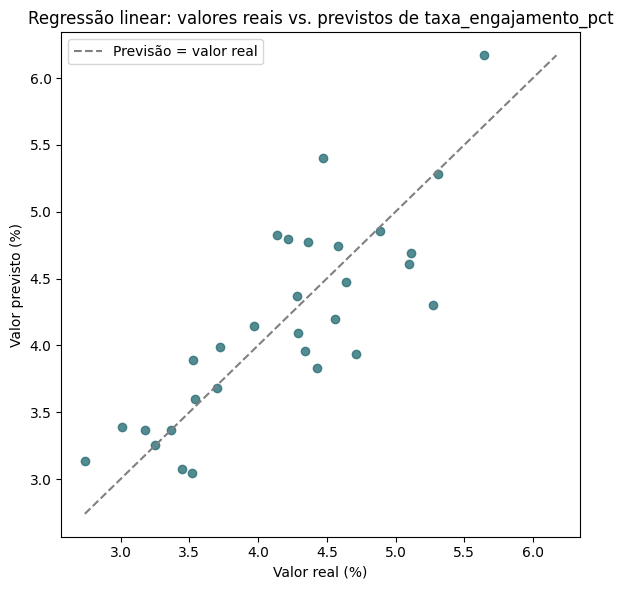

In [7]:
# Questão 7: estimativa de taxa_engajamento_pct (regressão)

from sklearn.linear_model import LinearRegression     # regressão linear
from sklearn.tree import DecisionTreeRegressor         # árvore de decisão para valores contínuos
from sklearn.metrics import mean_absolute_error, r2_score  # métricas de avaliação de regressão

df_q7 = pd.read_csv("dados/publicacoes_analise.csv")

caracteristicas = [
    "tema", "formato", "seguidores_autor", "videos_autor", "tamanho_legenda",
    "n_emojis", "n_hashtags", "hora", "dia_semana", "duracao_segundos",
]
X = pd.get_dummies(df_q7[caracteristicas], columns=["tema", "formato"], drop_first=True)
y = df_q7["taxa_engajamento_pct"]  # alvo contínuo (um número, não uma categoria)

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.25, random_state=42)
# Sem stratify aqui: stratify é para preservar proporção de CATEGORIAS, e o alvo
# desta questão é um número contínuo, não faz sentido "estratificar" por ele.

regressao_linear = LinearRegression().fit(X_treino, y_treino)
arvore_regressao = DecisionTreeRegressor(max_depth=4, random_state=42).fit(X_treino, y_treino)

# .predict aplica o modelo já treinado a dados novos (aqui, o conjunto de teste)
previsoes_linear = regressao_linear.predict(X_teste)
previsoes_arvore = arvore_regressao.predict(X_teste)

# MAE (Mean Absolute Error / Erro Absoluto Médio): média das diferenças absolutas
# entre valor real e previsto, na mesma unidade do alvo (pontos percentuais aqui).
# R² (coeficiente de determinação): entre 0 e 1 (pode ser negativo se o modelo for
# pior que simplesmente prever a média); mede a proporção da variação do alvo que
# o modelo consegue explicar.
comparacao = pd.DataFrame({
    "modelo": ["Regressão linear", "Árvore de regressão"],
    "MAE": [mean_absolute_error(y_teste, previsoes_linear), mean_absolute_error(y_teste, previsoes_arvore)],
    "R2": [r2_score(y_teste, previsoes_linear), r2_score(y_teste, previsoes_arvore)],
})
display(comparacao)

# Escolhe automaticamente o modelo com menor MAE (menor erro médio) para o gráfico
melhor_nome = comparacao.loc[comparacao["MAE"].idxmin(), "modelo"]
melhor_previsao = previsoes_linear if melhor_nome == "Regressão linear" else previsoes_arvore
print(f"Modelo com menor MAE: {melhor_nome}")

# --- Gráfico: real vs. previsto ---
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_teste, melhor_previsao, color="#2A6F77", alpha=0.8)

# Linha de referência: se a previsão fosse igual ao valor real, o ponto cairia
# exatamente sobre esta linha diagonal (y = x).
limite_min = min(y_teste.min(), melhor_previsao.min())
limite_max = max(y_teste.max(), melhor_previsao.max())
ax.plot([limite_min, limite_max], [limite_min, limite_max], linestyle="--", color="gray", label="Previsão = valor real")

ax.set_title(f"{melhor_nome}: valores reais vs. previstos de taxa_engajamento_pct")
ax.set_xlabel("Valor real (%)")
ax.set_ylabel("Valor previsto (%)")
ax.legend()
plt.tight_layout()
plt.show()

**Por que regressão, não classificação nem clusterização:** `taxa_engajamento_pct` é um número contínuo (ex.: 3,01%, 4,52%...), não uma categoria fixa nem um agrupamento sem rótulo — o objetivo é prever *quanto* vai ser essa taxa, não *em qual grupo* a publicação se encaixa. Isso é exatamente o que a regressão faz: estimar um valor numérico.

**Sobre as métricas:**
- **MAE**: em média, o quanto a previsão erra para mais ou para menos, na mesma escala da variável (pontos percentuais de engajamento). Quanto menor, melhor.
- **R²**: mede a proporção da variação da taxa de engajamento que o modelo consegue "explicar" com as características usadas; 1 seria um ajuste perfeito, 0 equivale a prever sempre a média.

**Sobre o gráfico:** cada ponto é uma publicação do conjunto de teste; a posição no eixo X é o valor real observado e no eixo Y é o valor que o modelo previu. Pontos próximos da linha tracejada (`y = x`) indicam previsões próximas do real; pontos distantes dela indicam erro maior.

**Resposta da Questão 7: estimativa (pontos-guia):**

- Confirme o tipo de aprendizado (regressão) e por que o alvo contínuo exige essa escolha.
- Explique o que o MAE mede, em suas palavras, e diga qual modelo teve o menor MAE nesta execução.
- Registre uma limitação: o modelo aprende associações estatísticas em 120 publicações de um único perfil fictício; não há como concluir que uma característica *causa* mais ou menos engajamento a partir dele.
- Até cinco frases.

---

## Questão 8: Priorização de divulgação

Nos dias finais da campanha, a equipe só consegue dar divulgação adicional a poucas publicações. Antes de uma nova publicação ir ao ar, a pergunta é: quais peças têm maior chance de receber a classificação **"merece divulgação adicional"**?

Use **somente** `dados/publicacoes_analise.csv`. Crie `mereceu_divulgacao_adicional`: valor 1 quando `taxa_engajamento_pct` estiver acima do percentil 75 da própria base, e 0 nos demais.

1. Na Markdown, diga qual tipo de aprendizado de máquina é adequado: regressão, classificação ou clusterização, e explique brevemente por que os outros dois não respondem diretamente a essa decisão.
2. Use apenas características disponíveis antes da publicação: `tema`, `formato`, `seguidores_autor`, `videos_autor`, `tamanho_legenda`, `n_emojis`, `n_hashtags`, `hora`, `dia_semana` e `duracao_segundos`. Transforme as categorias em colunas numéricas quando necessário. Não use identificador, alcance, interações ou `taxa_engajamento_pct`: isso seria vazamento de dados.
3. Reserve 75% das publicações para treino e 25% para teste, usando `random_state=42` e preservando a proporção de publicações que mereceram divulgação adicional nos dois conjuntos.
4. Escolha três classificadores desta lista e compare-os: regressão logística, árvore de classificação, Random Forest, Extra Trees, AdaBoost e Gaussian Naive Bayes.
5. No conjunto de teste, apresente precisão, recall e F1 dos três modelos em uma tabela e exiba a matriz de confusão do modelo com maior F1.
6. Na regressão logística já ajustada e no mesmo conjunto de teste, compare os cortes 0,50 e 0,30 para decidir quando uma publicação recebe divulgação adicional. Apresente precisão, recall e F1 dos dois cortes em uma tabela.

Na resposta final, informe o modelo e o corte escolhidos. Explique, em até seis frases, o que falso positivo e falso negativo significam para a equipe de comunicação e justifique sua decisão com base no trade-off observado entre precisão e recall. Você pode consultar os materiais das aulas para lembrar a sintaxe; as decisões e interpretações devem ser suas.

**Resposta da Questão 8.1: tipo de modelo (pontos-guia):**

- O alvo `mereceu_divulgacao_adicional` só tem dois valores possíveis (0 ou 1) — isso aponta para qual dos três tipos de aprendizado?
- Por que regressão (que estima um número contínuo) não se encaixa aqui?
- Por que clusterização (que agrupa dados sem usar um rótulo conhecido) também não responde à pergunta, já que aqui já sabemos o rótulo de cada publicação no histórico?
- Até quatro frases.

In [8]:
# Questão 8: comparação de classificadores para priorizar divulgação adicional

from sklearn.preprocessing import StandardScaler       # padroniza a escala das variáveis numéricas
from sklearn.linear_model import LogisticRegression     # regressão logística (classificador)
from sklearn.ensemble import RandomForestClassifier      # Random Forest
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

df_q8 = pd.read_csv("dados/publicacoes_analise.csv")

# Mesmo alvo da Questão 6, recriado aqui de forma independente, como pede o enunciado.
limite_p75 = df_q8["taxa_engajamento_pct"].quantile(0.75)
df_q8["mereceu_divulgacao_adicional"] = (df_q8["taxa_engajamento_pct"] > limite_p75).astype(int)

caracteristicas = [
    "tema", "formato", "seguidores_autor", "videos_autor", "tamanho_legenda",
    "n_emojis", "n_hashtags", "hora", "dia_semana", "duracao_segundos",
]
X = pd.get_dummies(df_q8[caracteristicas], columns=["tema", "formato"], drop_first=True)
y = df_q8["mereceu_divulgacao_adicional"]

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# StandardScaler reescala cada característica para média 0 e desvio-padrão 1.
# É necessário para a regressão logística: como seguidores_autor (milhares) e
# n_emojis (unidades) estão em escalas muito diferentes, sem padronizar o algoritmo
# de otimização por trás da regressão logística converge mal (e o scikit-learn avisa isso).
# Árvores e Random Forest não precisam de padronização (decidem por limiares, não por
# distância), mas aplicar não prejudica o resultado delas.
escalador = StandardScaler()
X_treino_escalado = escalador.fit_transform(X_treino)  # calcula média/desvio no treino e já aplica
X_teste_escalado = escalador.transform(X_teste)         # aplica ao teste a MESMA transformação do treino

# Três classificadores escolhidos da lista do enunciado: regressão logística,
# árvore de classificação e Random Forest.
modelos = {
    "Regressão logística": (LogisticRegression(max_iter=1000, random_state=42), True),
    "Árvore de classificação": (DecisionTreeClassifier(max_depth=4, random_state=42, class_weight="balanced"), False),
    "Random Forest": (RandomForestClassifier(random_state=42, class_weight="balanced"), False),
}
# O segundo item de cada tupla indica se aquele modelo usa os dados PADRONIZADOS
# (True, no caso da regressão logística) ou os dados originais (False, para as árvores).

linhas_resultado = []
previsoes_por_modelo = {}
for nome, (modelo, usa_escala) in modelos.items():
    X_treino_uso = X_treino_escalado if usa_escala else X_treino
    X_teste_uso = X_teste_escalado if usa_escala else X_teste
    modelo.fit(X_treino_uso, y_treino)
    predito = modelo.predict(X_teste_uso)
    previsoes_por_modelo[nome] = predito
    linhas_resultado.append({
        "modelo": nome,
        # precision_score: dentre as publicações que o modelo disse que "mereciam", quantas de fato mereciam.
        "precisao": precision_score(y_teste, predito),
        # recall_score: dentre as publicações que de fato mereciam, quantas o modelo conseguiu identificar.
        "recall": recall_score(y_teste, predito),
        # f1_score: média harmônica entre precisão e recall; resume os dois em um só número.
        "f1": f1_score(y_teste, predito),
    })

tabela_metricas = pd.DataFrame(linhas_resultado).sort_values("f1", ascending=False)
display(tabela_metricas)

melhor_modelo_nome = tabela_metricas.iloc[0]["modelo"]
print(f"Modelo com maior F1 no teste: {melhor_modelo_nome}")

# confusion_matrix cruza previsão x realidade em uma tabela 2x2:
# [[verdadeiro_negativo, falso_positivo], [falso_negativo, verdadeiro_positivo]]
matriz = confusion_matrix(y_teste, previsoes_por_modelo[melhor_modelo_nome])
print("Matriz de confusão (linhas = real, colunas = previsto), ordem das classes [0, 1]:")
print(matriz)

# --- Comparação de cortes de probabilidade na regressão logística ---
regressao_logistica = modelos["Regressão logística"][0]
# predict_proba devolve, para cada linha, a probabilidade estimada de cada classe;
# [:, 1] seleciona a coluna da probabilidade da classe 1 ("mereceu divulgação").
probabilidades = regressao_logistica.predict_proba(X_teste_escalado)[:, 1]

linhas_corte = []
for corte in [0.50, 0.30]:
    # Em vez de usar .predict() (que usa corte fixo em 0,50), aplicamos o corte manualmente:
    # a publicação é classificada como 1 se a probabilidade estimada for >= o corte escolhido.
    predito_no_corte = (probabilidades >= corte).astype(int)
    linhas_corte.append({
        "corte": corte,
        "precisao": precision_score(y_teste, predito_no_corte),
        "recall": recall_score(y_teste, predito_no_corte),
        "f1": f1_score(y_teste, predito_no_corte),
    })

tabela_cortes = pd.DataFrame(linhas_corte)
display(tabela_cortes)

,modelo,precisao,recall,f1
0,Regressão logística,0.875,1.000000,0.933333
1,Árvore de classificação,0.500,0.714286,0.588235
2,Random Forest,1.000,0.285714,0.444444


Modelo com maior F1 no teste: Regressão logística
Matriz de confusão (linhas = real, colunas = previsto), ordem das classes [0, 1]:
[[22  1]
 [ 0  7]]


,corte,precisao,recall,f1
0,0.5,0.875,1.0,0.933333
1,0.3,0.700,1.0,0.823529


**Conceitos novos nesta questão:**
- **`StandardScaler`**: subtrai a média e divide pelo desvio-padrão de cada característica, deixando todas em escalas comparáveis. Necessário para a regressão logística (que otimiza com base em distâncias/gradientes) funcionar bem quando as variáveis originais têm grandezas muito diferentes (`seguidores_autor` na casa dos milhares vs. `n_emojis` de 0 a poucas unidades).
- **Precisão vs. recall vs. F1**: precisão responde "das vezes que o modelo disse 'sim', quantas estavam certas?"; recall responde "de todos os casos que realmente eram 'sim', quantos o modelo pegou?"; F1 combina os dois em um único número, útil quando não dá para otimizar os dois separadamente ao mesmo tempo.
- **`confusion_matrix`**: tabela 2×2 que separa acertos e erros por tipo — verdadeiro positivo, falso positivo, verdadeiro negativo, falso negativo — a base para calcular precisão e recall manualmente, se necessário.
- **`predict_proba` e corte de decisão**: por padrão, `.predict()` classifica como 1 quando a probabilidade estimada é ≥ 0,50. Usar `predict_proba` e comparar manualmente com outros cortes (aqui, 0,30) permite simular "e se fôssemos mais permissivos para marcar uma publicação como prioritária?" — geralmente aumentando o recall (menos falsos negativos) às custas da precisão (mais falsos positivos), ou vice-versa.

**Atenção:** o `X_teste_escalado` é transformado com `escalador.transform` (não `fit_transform`) porque a escala (média e desvio-padrão) deve ser aprendida **somente** com os dados de treino; usar o teste para calcular essa escala também seria uma forma sutil de vazamento de informação do teste para o treino.

**Resposta da Questão 8: decisão e riscos de erro (pontos-guia):**

- Diga qual modelo teve o maior F1 nesta execução e qual corte (0,50 ou 0,30) você escolheria para a regressão logística, olhando a tabela de precisão/recall/F1 dos dois cortes.
- No contexto da equipe de comunicação: o que significa um **falso positivo** aqui (dar divulgação extra a uma publicação que não precisava)? E um **falso negativo** (deixar de dar divulgação extra a uma publicação que se beneficiaria dela)?
- Qual erro é mais custoso para a equipe, considerando que os espaços de divulgação são escassos? Use isso para justificar sua escolha de modelo/corte.
- Até seis frases.

---
# Guia de Referência

Referência rápida dos principais comandos usados ao longo deste notebook.

## Python

- `import biblioteca as apelido`: carrega uma biblioteca e permite chamá-la pelo apelido combinado (`pd`, `plt`...).
- `def funcao(parametro): ... return valor`: define uma função reutilizável (usada em `parse_data`).
- `for item in colecao:` / *list comprehension* `[expr for item in colecao]`: percorre uma coleção; a comprehension monta uma lista nova em uma linha (usada para os rótulos do gráfico da Questão 5).
- `re.match(padrao, texto)`: testa se o início de uma string casa com um padrão de expressão regular.
- `f"texto {variavel}"`: *f-string*, forma de inserir o valor de uma variável dentro de um texto.

## Pandas

```python
df.head()                                   # primeiras linhas
df.shape                                    # (linhas, colunas)
df.isna().sum()                             # ausências por coluna
df.drop_duplicates(subset="col", keep="first")   # remove duplicidade
df["col"].str.strip().str.lower()           # padroniza texto
pd.to_datetime(valor, format="...")         # converte texto em data
pd.to_numeric(df["col"], errors="coerce")   # converte texto em número, gerando NaN se falhar
df.groupby("col")["outra"].agg(a="count", b="median")  # agrega com nomes de coluna próprios
df.sort_values("col", ascending=False)      # ordena
df[(df["a"] == x) & (df["b"] >= y)]         # filtro com múltiplas condições
pd.get_dummies(df[cols], columns=[...], drop_first=True)  # transforma categorias em números
```

## NumPy / estatística

- `.quantile(0.75)`: calcula o percentil 75 de uma coluna.
- `.median()` vs `.mean()`: mediana é mais robusta a valores extremos que a média.

## Machine learning (scikit-learn)

```python
train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)  # separa treino/teste
StandardScaler().fit_transform(X_treino)     # aprende e aplica a padronização no treino
StandardScaler().transform(X_teste)          # aplica ao teste a MESMA padronização

DecisionTreeClassifier(max_depth=4, random_state=42, class_weight="balanced")
DecisionTreeRegressor(max_depth=4, random_state=42)
LinearRegression()
LogisticRegression(max_iter=1000, random_state=42)
RandomForestClassifier(random_state=42, class_weight="balanced")

modelo.fit(X_treino, y_treino)               # treina
modelo.predict(X_teste)                      # prevê classes/valores
modelo.predict_proba(X_teste)[:, 1]          # prevê probabilidade da classe 1
modelo.feature_importances_                  # importância de cada característica (árvores)

mean_absolute_error(y_teste, previsto)       # erro médio absoluto (regressão)
r2_score(y_teste, previsto)                  # proporção da variância explicada (regressão)
precision_score(y_teste, previsto)           # precisão (classificação)
recall_score(y_teste, previsto)              # recall (classificação)
f1_score(y_teste, previsto)                  # F1 (classificação)
confusion_matrix(y_teste, previsto)          # tabela de acertos/erros por classe
```

## Visualização (matplotlib)

```python
fig, ax = plt.subplots(figsize=(l, a))
ax.plot(...) / ax.bar(...) / ax.barh(...) / ax.scatter(...)
ax.set_title(...); ax.set_xlabel(...); ax.set_ylabel(...)
plt.figtext(x, y, "Fonte: ...", fontsize=8)   # texto de fonte fora da área do gráfico
plt.tight_layout(); plt.show()
```

## Erros e armadilhas encontrados neste notebook

- **Datas em formatos mistos**: um único `pd.to_datetime(..., format="mixed")` sem tratamento por padrão pode interpretar `"05/08/2026"` (dia/mês/ano) como mês/dia e trocar o dia 5 de agosto pelo dia 8 de maio — por isso a detecção do formato por regex, linha a linha.
- **Duplicidade não é sempre "linha idêntica"**: aqui a duplicata tinha o mesmo `id_publicacao` e os mesmos valores; em outras bases pode haver duplicidade "quase igual" que exige critério adicional.
- **Ausência em campo usado numa fórmula**: preencher com média/zero alteraria artificialmente a métrica calculada a partir dele; descartar a linha (quando são poucas) é mais transparente.
- **Vazamento de dados (data leakage)**: usar `alcance`, curtidas ou a própria taxa como característica de entrada nas Questões 6-8 inflaria artificialmente o desempenho do modelo, porque essas informações não existem antes de a publicação ir ao ar.
- **Escala das variáveis para regressão logística**: sem `StandardScaler`, o otimizador por trás da regressão logística pode não convergir quando as características têm grandezas muito diferentes (ex.: `seguidores_autor` na casa de milhares vs. `n_emojis` de poucas unidades).
- **`fit_transform` no treino, `transform` no teste**: usar `fit_transform` também no teste vazaria estatísticas do teste (média, desvio-padrão) para dentro do pipeline, inflando artificialmente a avaliação.
- **Associação não é causalidade**: em todas as questões analíticas e de modelo, os resultados descrevem padrões observados nesta base sintética específica — não comprovam que um tema, formato ou horário *causa* mais engajamento ou utilidade.